# A ParameterWithSetpoints Example with Dual Setpoints

This notebook explains how you can account for dual setpoints using `ParameterWithSetpoints`. The basics of writing drivers using `ParameterWithSetpoints` is covered in the notebook named [Simple Example of ParameterWithSetpoints](../Parameters/Simple-Example-of-ParameterWithSetpoints.ipynb).

In this example we consider a dummy instrument that can return a time trace or the discreet Fourier transform (magnitude square) of that trace. The setpoints are accounted for in an easy way.

In [1]:
from pathlib import Path
from typing import TYPE_CHECKING

if TYPE_CHECKING:
    from typing_extensions import Unpack

import numpy as np
import numpy.typing as npt

import qcodes.validators as vals
from qcodes.dataset import (
    Measurement,
    initialise_or_create_database_at,
    load_or_create_experiment,
    plot_dataset,
)
from qcodes.instrument import Instrument, InstrumentBaseKWArgs
from qcodes.parameters import Parameter, ParameterWithSetpoints

In [2]:
def timetrace(npts: int, dt: float) -> npt.NDArray[np.float64]:
    """
    A very realistic-looking signal
    """
    # freq = 10/(dt*npts)
    # decay = 1/(dt*npts)
    freq = 10
    decay = 1
    time = np.linspace(0, npts * dt, npts, endpoint=False)
    signal = np.exp(-decay * time) * np.sin(2 * np.pi * freq * time)
    noise = 0.1 * np.random.default_rng().standard_normal(npts)
    return signal + noise

In [3]:
class TimeTrace(ParameterWithSetpoints[npt.NDArray[np.float64], "OzzyLowScope"]):
    def get_raw(self) -> npt.NDArray[np.float64]:
        npts = self.instrument.npts()
        dt = self.instrument.dt()

        return timetrace(npts, dt)


class Periodogram(ParameterWithSetpoints[npt.NDArray[np.float64], "OzzyLowScope"]):
    def get_raw(self) -> npt.NDArray[np.float64]:
        tt = self.instrument.trace()

        return np.abs(np.fft.fft(tt)) ** 2


class TimeAxis(Parameter[npt.NDArray[np.float64], "OzzyLowScope"]):
    def get_raw(self) -> npt.NDArray[np.float64]:
        npts = self.instrument.npts()
        dt = self.instrument.dt()
        return np.linspace(0, dt * npts, npts, endpoint=False)


class FrequencyAxis(Parameter[npt.NDArray[np.float64], "OzzyLowScope"]):
    def get_raw(self) -> npt.NDArray[np.float64]:
        npts = self.instrument.npts()
        dt = self.instrument.dt()
        return np.linspace(0, 1 / dt, npts)


class OzzyLowScope(Instrument):
    def __init__(self, name: str, **kwargs: "Unpack[InstrumentBaseKWArgs]"):
        super().__init__(name, **kwargs)

        self.npts: Parameter[int, OzzyLowScope] = self.add_parameter(
            name="npts",
            initial_value=500,
            label="Number of points",
            get_cmd=None,
            set_cmd=None,
        )

        self.dt: Parameter[float, OzzyLowScope] = self.add_parameter(
            name="dt",
            initial_value=1e-3,
            label="Time resolution",
            unit="s",
            get_cmd=None,
            set_cmd=None,
        )

        self.time_axis: TimeAxis = self.add_parameter(
            name="time_axis",
            label="Time",
            unit="s",
            vals=vals.Arrays(shape=(self.npts,)),
            parameter_class=TimeAxis,
        )

        self.freq_axis: FrequencyAxis = self.add_parameter(
            name="freq_axis",
            label="Frequency",
            unit="Hz",
            vals=vals.Arrays(shape=(self.npts,)),
            parameter_class=FrequencyAxis,
        )

        self.trace: TimeTrace = self.add_parameter(
            name="trace",
            label="Signal",
            unit="V",
            vals=vals.Arrays(shape=(self.npts,)),
            setpoints=(self.time_axis,),
            parameter_class=TimeTrace,
        )

        self.periodogram: Periodogram = self.add_parameter(
            name="periodogram",
            label="Periodogram",
            unit="V^2/Hz",
            vals=vals.Arrays(shape=(self.npts,)),
            setpoints=(self.freq_axis,),
            parameter_class=Periodogram,
        )

In [4]:
osc = OzzyLowScope("osc")

In [5]:
tutorial_db_path = Path.cwd().parent / "example_output" / "tutorial_doND.db"
initialise_or_create_database_at(tutorial_db_path)
load_or_create_experiment(experiment_name="tutorial_exp", sample_name="no sample")

tutorial_exp#no sample#1@/home/runner/work/Qcodes/Qcodes/docs/examples/example_output/tutorial_doND.db
------------------------------------------------------------------------------------------------------

## Measurement 1: Time Trace

In [6]:
timemeas = Measurement()
timemeas.register_parameter(osc.trace)

osc.dt(0.001)

with timemeas.run() as datasaver:
    datasaver.add_result((osc.trace, osc.trace.get()))

dataset = datasaver.dataset

Starting experimental run with id: 1. 


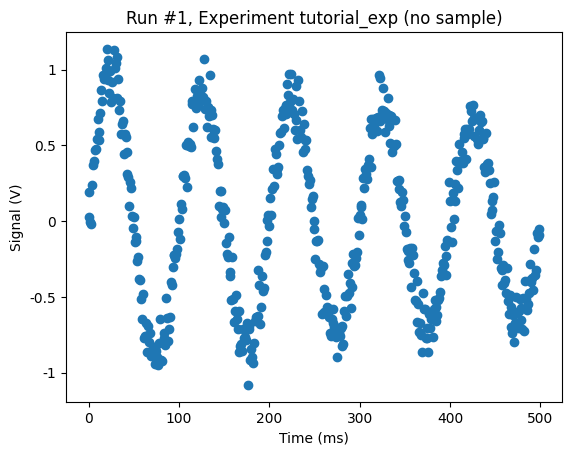

In [7]:
_ = plot_dataset(dataset)

In [8]:
osc.dt(0.01)  # make the trace 10 times longer

with timemeas.run() as datasaver:
    datasaver.add_result((osc.trace, osc.trace.get()))

dataset = datasaver.dataset

Starting experimental run with id: 2. 


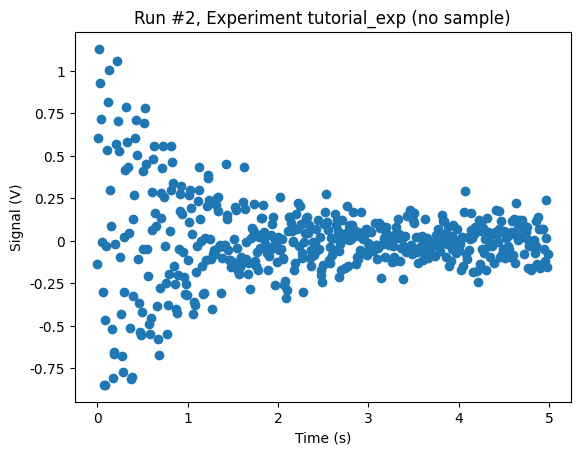

In [9]:
_ = plot_dataset(dataset)

## Measurement 2: Periodogram

In [10]:
freqmeas = Measurement()
freqmeas.register_parameter(osc.periodogram)

osc.dt(0.01)

with freqmeas.run() as datasaver:
    datasaver.add_result((osc.periodogram, osc.periodogram.get()))

dataid = datasaver.dataset

Starting experimental run with id: 3. 


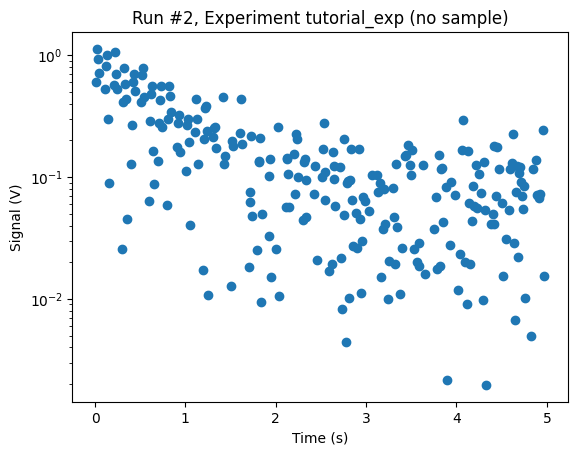

In [11]:
axs, cbax = plot_dataset(dataset)
aa = axs[0]
aa.set_yscale("log")

Just for the fun of it, let's make a measurement with the averaged periodogram.

In [12]:
no_of_avgs = 100

with freqmeas.run() as datasaver:
    temp_per = osc.periodogram()

    for _ in range(no_of_avgs - 1):
        temp_per += osc.periodogram()

    datasaver.add_result(
        (osc.periodogram, temp_per / no_of_avgs), (osc.freq_axis, osc.freq_axis.get())
    )

dataset = datasaver.dataset

Starting experimental run with id: 4. 


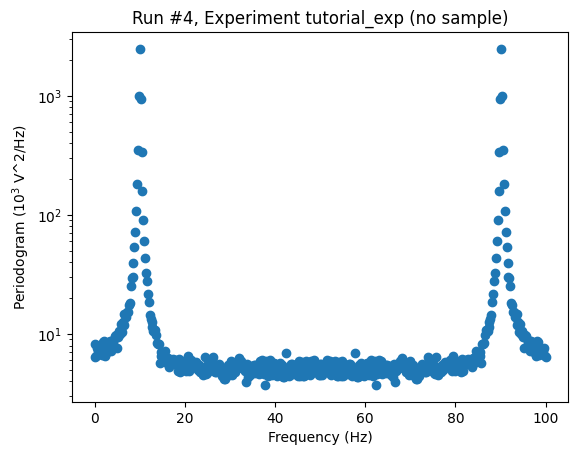

In [13]:
axs, cbax = plot_dataset(dataset)
aa = axs[0]
aa.set_yscale("log")

## Measurement 3: 2D Sweeping

In [14]:
meas = Measurement()
meas.register_parameter(osc.npts)
meas.register_parameter(osc.trace, setpoints=[osc.npts], paramtype="numeric")

with meas.run() as datasaver:
    osc.dt(0.001)

    for npts in [200, 400, 600, 800, 1000, 1200]:
        osc.npts(npts)
        datasaver.add_result((osc.trace, osc.trace.get()), (osc.npts, osc.npts()))

dataset = datasaver.dataset

Starting experimental run with id: 5. 


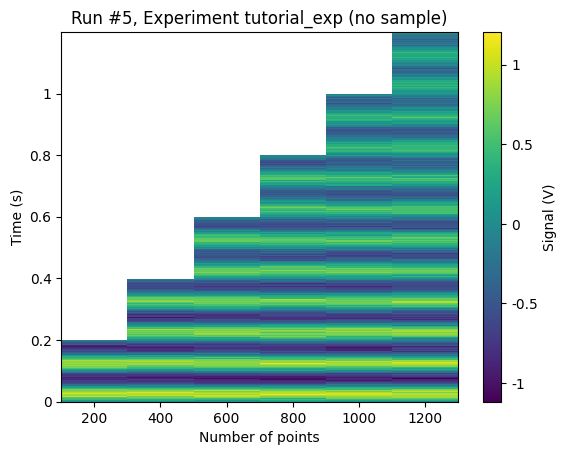

In [15]:
_ = plot_dataset(dataset)